In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Desktop\3MTT\Online classes\HR_Analytics.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1480, 38)

Columns: ['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First 5 rows:


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Check unique values in key columns
print("\nAttrition values:", df['Attrition'].unique())
print("Departments:", df['Department'].unique())
print("Age Groups:", df['AgeGroup'].unique())

Missing values:
YearsWithCurrManager    57
dtype: int64

Duplicate rows: 7

Attrition values: ['Yes' 'No']
Departments: ['Research & Development' 'Sales' 'Human Resources']
Age Groups: ['18-25' '26-35' '36-45' '46-55' '55+']


In [5]:
# Check missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Fix missing values
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].fillna(0)

# Verify fix
print("\nAfter fix - missing values:", df['YearsWithCurrManager'].isnull().sum())

# Check key columns
print("\nAttrition values:", df['Attrition'].unique())
print("Departments:", df['Department'].unique())
print("Age Groups:", df['AgeGroup'].unique())

Missing values:
YearsWithCurrManager    57
dtype: int64

Duplicate rows: 7

After fix - missing values: 0

Attrition values: ['Yes' 'No']
Departments: ['Research & Development' 'Sales' 'Human Resources']
Age Groups: ['18-25' '26-35' '36-45' '46-55' '55+']


In [6]:
# Remove 7 duplicates
df = df.drop_duplicates()
print("After removing duplicates:", len(df), "rows remaining")

# Drop useless columns
df = df.drop(columns=['StandardHours', 'Over18', 'EmployeeCount'])
print("Columns remaining:", len(df.columns))
print("Cleaned data shape:", df.shape)

After removing duplicates: 1473 rows remaining
Columns remaining: 35
Cleaned data shape: (1473, 35)


In [7]:
# Check missing values again
print("Missing before fix:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Calculate median
median_value = df['YearsWithCurrManager'].median()
print(f"\nMedian YearsWithCurrManager: {median_value}")

# Fill missing with median
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].fillna(median_value)

# Verify
print(f"\nMissing after fix: {df['YearsWithCurrManager'].isnull().sum()}")
print("✅ All missing values fixed!")

Missing before fix:
Series([], dtype: int64)

Median YearsWithCurrManager: 3.0

Missing after fix: 0
✅ All missing values fixed!


In [8]:
# Save cleaned data to Excel
df.to_excel(r"C:\Users\User\Downloads\HR_Analytics_Cleaned.xlsx", 
            index=False)
print("✅ Cleaned file saved!")
print(f"Shape: {df.shape}")

✅ Cleaned file saved!
Shape: (1473, 35)


In [9]:
df

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,3,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,3,1,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,3,4,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,3,4,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,3,4,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,3,4,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,3,4,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,3,4,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,3,2,1,12,3,3,11,7,1,9.0


Attrition Count:
Attrition
No     1236
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


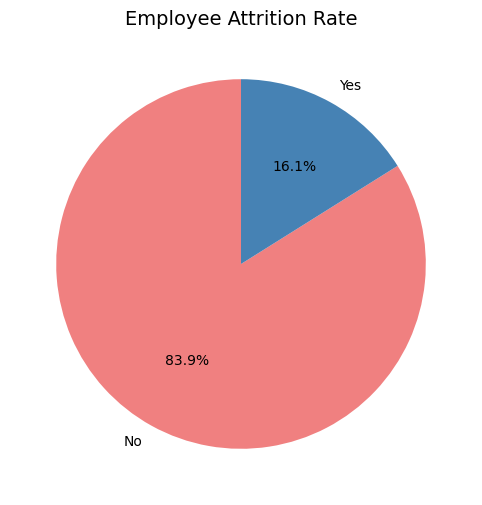

In [10]:
# Overall attrition rate
attrition_count = df['Attrition'].value_counts()
attrition_rate = (attrition_count['Yes'] / len(df)) * 100

print("Attrition Count:")
print(attrition_count)
print(f"\nAttrition Rate: {attrition_rate:.1f}%")

# Pie chart
plt.figure(figsize=(8,6))
attrition_count.plot(kind='pie', 
                     autopct='%1.1f%%',
                     colors=['lightcoral', 'steelblue'],
                     startangle=90)
plt.title('Employee Attrition Rate', fontsize=14)
plt.ylabel('')
plt.show()

Attrition by Department:
Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: EmpID, dtype: float64


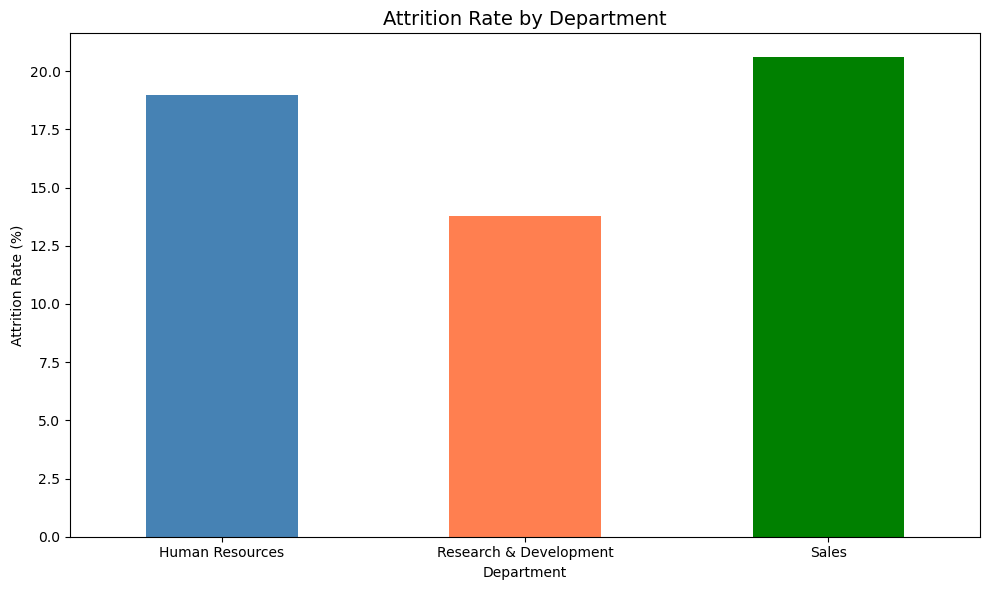

In [11]:
# Attrition by Department
dept_attrition = df[df['Attrition']=='Yes'].groupby('Department')['EmpID'].count()
dept_total = df.groupby('Department')['EmpID'].count()
dept_rate = (dept_attrition / dept_total * 100).round(1)

print("Attrition by Department:")
print(dept_rate)

# Bar chart
plt.figure(figsize=(10,6))
dept_rate.plot(kind='bar', color=['steelblue','coral','green'])
plt.title('Attrition Rate by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Attrition by Age Group:
AgeGroup
18-25    35.8
26-35    19.1
36-45     9.1
46-55    11.5
55+      17.0
Name: EmpID, dtype: float64


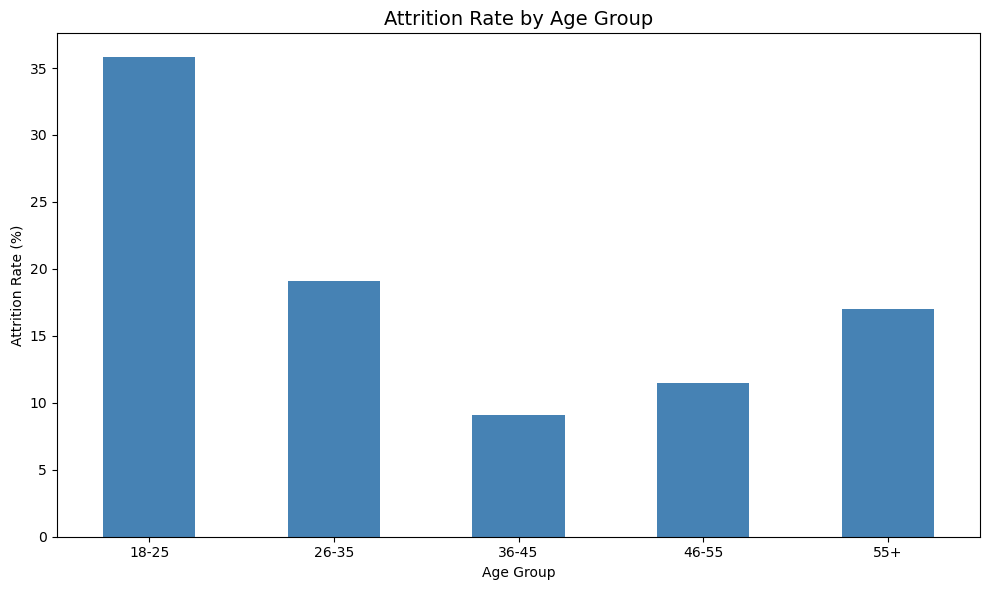

In [12]:
# Attrition by Age Group
age_attrition = df[df['Attrition']=='Yes'].groupby('AgeGroup')['EmpID'].count()
age_total = df.groupby('AgeGroup')['EmpID'].count()
age_rate = (age_attrition / age_total * 100).round(1)

print("Attrition by Age Group:")
print(age_rate)

# Bar chart
plt.figure(figsize=(10,6))
age_rate.plot(kind='bar', color='steelblue')
plt.title('Attrition Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Attrition Rate by Overtime:
OverTime
No     10.4
Yes    30.5
Name: EmpID, dtype: float64


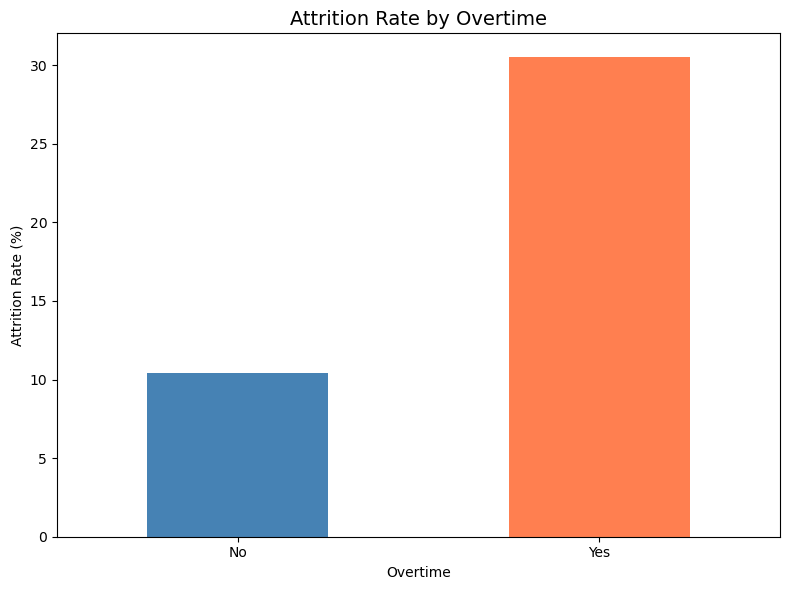

In [13]:
# Overtime vs Attrition
overtime_attrition = df[df['Attrition']=='Yes'].groupby('OverTime')['EmpID'].count()
overtime_total = df.groupby('OverTime')['EmpID'].count()
overtime_rate = (overtime_attrition / overtime_total * 100).round(1)

print("Attrition Rate by Overtime:")
print(overtime_rate)

# Bar chart
plt.figure(figsize=(8,6))
overtime_rate.plot(kind='bar', color=['steelblue','coral'])
plt.title('Attrition Rate by Overtime', fontsize=14)
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Monthly Income by Job Role:
JobRole
Manager                      17182.0
Research Director            16034.0
Healthcare Representative     7547.0
Manufacturing Director        7295.0
Sales Executive               6924.0
Human Resources               4236.0
Research Scientist            3240.0
Laboratory Technician         3235.0
Sales Representative          2630.0
Name: MonthlyIncome, dtype: float64


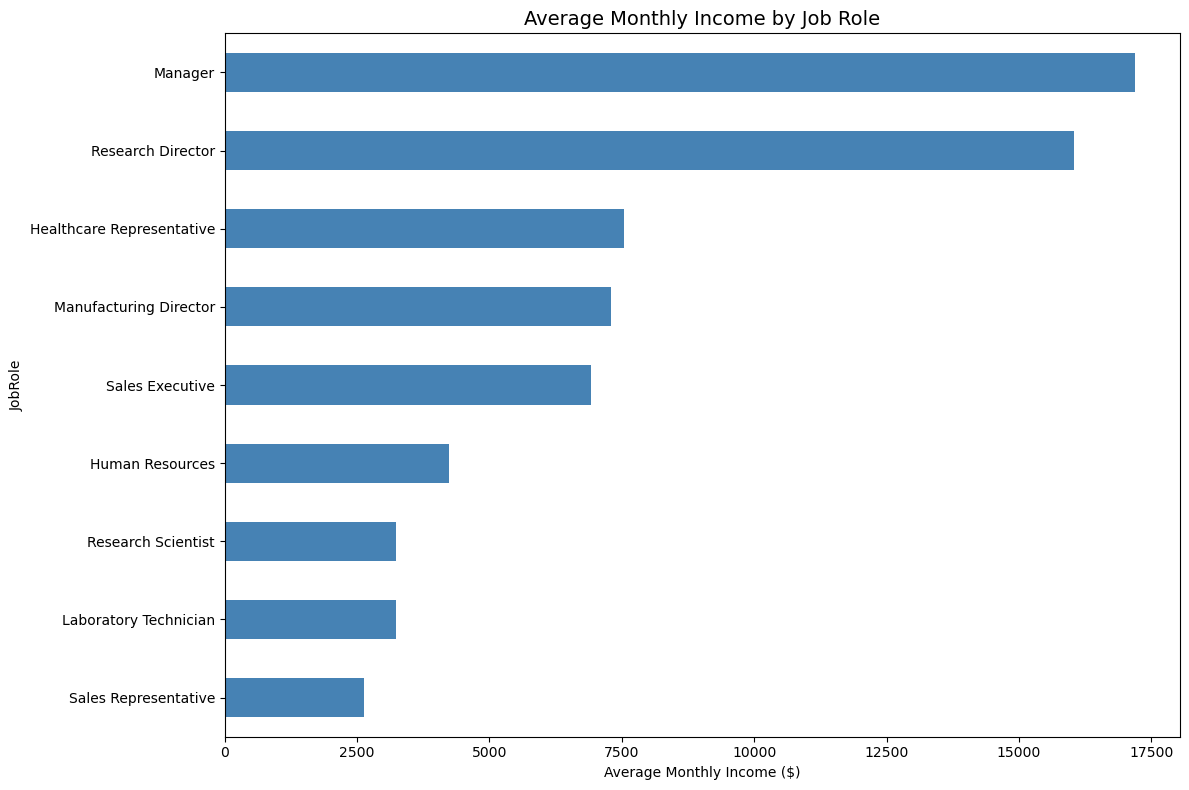

In [14]:
# Average salary by job role
salary_by_role = df.groupby('JobRole')['MonthlyIncome'].mean().round(0)
salary_by_role = salary_by_role.sort_values(ascending=False)
print("Average Monthly Income by Job Role:")
print(salary_by_role)

# Horizontal bar chart
plt.figure(figsize=(12,8))
salary_by_role.sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Monthly Income by Job Role', fontsize=14)
plt.xlabel('Average Monthly Income ($)')
plt.tight_layout()
plt.show()